# 04 Sentence Embedding Similarity

**Project:** LLMOps Monitoring & Evaluation Platform

**Notebook:** `04-sentence-embedding-similarity.ipynb`

In [6]:
# ==========================================
# Notebook 04
# Sentence Embedding Similarity
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("../data/golden_dataset.csv")

df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN


In [8]:
reference = "AWS is Amazon Web Services, a cloud platform."

prediction = "Amazon Web Services provides cloud infrastructure."

In [10]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [11]:
reference_embedding = embedding_model.encode(reference)

prediction_embedding = embedding_model.encode(prediction)

In [12]:
print(reference_embedding.shape)

(384,)


In [13]:
similarity = cosine_similarity(
    reference_embedding.reshape(1, -1), prediction_embedding.reshape(1, -1)
)[0][0]

In [14]:
print(f"Similarity: {similarity:.4f}")

Similarity: 0.8126


In [15]:
def sentence_similarity(prediction, reference, model):

    pred_embedding = model.encode(prediction)

    ref_embedding = model.encode(reference)

    score = cosine_similarity(
        pred_embedding.reshape(1, -1), ref_embedding.reshape(1, -1)
    )[0][0]

    return float(score)

In [16]:
sentence_similarity(prediction, reference, embedding_model)

0.8125919699668884

In [17]:
similarity_scores = []

In [18]:
for _, row in df.iterrows():

    score = sentence_similarity(
        row["generated_response"], row["ground_truth"], embedding_model
    )

    similarity_scores.append(score)

In [19]:
embedding_df = pd.DataFrame({"embedding_similarity": similarity_scores})

In [20]:
embedding_df.head()

,embedding_similarity
0,0.919994
1,0.911832
2,0.885961
3,0.874929
4,0.878420


In [21]:
evaluation_df = pd.concat([df, embedding_df], axis=1)

In [22]:
evaluation_df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length,embedding_similarity
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0,0.919994
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0,0.911832
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0,0.885961
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN,0.874929
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN,0.878420


In [23]:
evaluation_df["embedding_similarity"].mean()

0.5880058348178864

In [24]:
def similarity_label(score):

    if score >= 0.90:
        return "Excellent"

    elif score >= 0.80:
        return "Good"

    elif score >= 0.70:
        return "Average"

    return "Poor"

In [25]:
evaluation_df["similarity_label"] = evaluation_df["embedding_similarity"].apply(
    similarity_label
)

In [26]:
bertscore_df = pd.read_csv("../evaluation_results/bertscore_results.csv")

In [27]:
comparison_df = pd.DataFrame(
    {
        "embedding_similarity": evaluation_df["embedding_similarity"],
        "bertscore_f1": bertscore_df["bertscore_f1"],
    }
)

In [28]:
comparison_df.head()

,embedding_similarity,bertscore_f1
0,0.919994,0.928702
1,0.911832,0.916648
2,0.885961,0.956872
3,0.874929,0.930819
4,0.878420,0.930106


In [29]:
comparison_df.corr()

,embedding_similarity,bertscore_f1
embedding_similarity,1.000000,0.980227
bertscore_f1,0.980227,1.000000


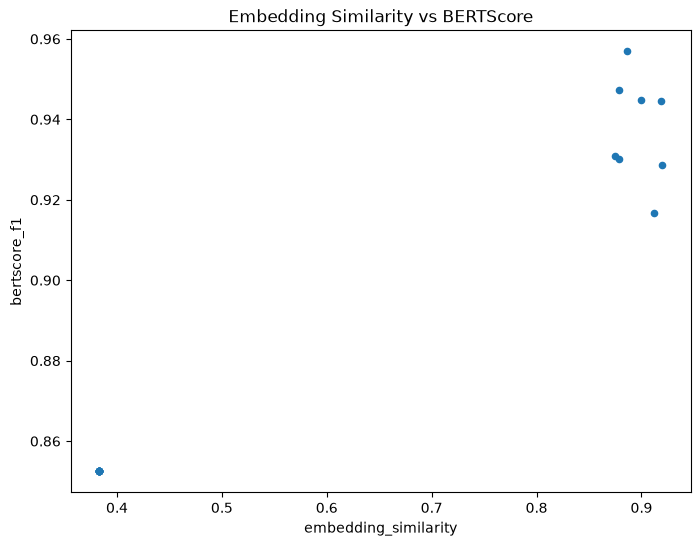

In [30]:
comparison_df.plot(
    kind="scatter", x="embedding_similarity", y="bertscore_f1", figsize=(8, 6)
)

plt.title("Embedding Similarity vs BERTScore")

plt.show()

In [31]:
documents = [
    "AWS cloud platform",
    "Azure cloud services",
    "Google Cloud storage",
    "Oracle database services",
]

In [32]:
doc_embeddings = embedding_model.encode(documents)

In [33]:
query = "Amazon cloud services"

In [34]:
query_embedding = embedding_model.encode(query)

In [35]:
scores = cosine_similarity(query_embedding.reshape(1, -1), doc_embeddings)[0]

In [36]:
for doc, score in zip(documents, scores):

    print(f"{doc}: " f"{score:.4f}")

AWS cloud platform: 0.7921
Azure cloud services: 0.6779
Google Cloud storage: 0.5132
Oracle database services: 0.3250


In [37]:
best_idx = np.argmax(scores)

documents[best_idx]

'AWS cloud platform'

In [38]:
evaluation_df.to_csv(
    "../evaluation_results/embedding_similarity_results.csv", index=False
)

In [39]:
{"query": "...", "response": "...", "embedding_similarity": 0.92}

{'query': '...', 'response': '...', 'embedding_similarity': 0.92}